In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1_old import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
CUDA_LAUNCH_BLOCKING=1

In [2]:
path_existence = []
data_prodromal=[]
data_swedd=[]
data_control=[]
data_PD = []
count_control = 0
count_PD = 0
count_swedd = 0
count_prodromal = 0
with open('PD1.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'PD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_PD=count_PD+1
            data_PD.append(row)
            
with open('control.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Control/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_control=count_control+1
            data_control.append(row)
            
with open('swedd.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'SWEDD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_swedd=count_swedd+1
            data_swedd.append(row)

with open('prodromal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Prodromal/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_prodromal=count_prodromal+1
            data_prodromal.append(row)
print(count_PD) 
print(count_control) 
print(count_swedd) 
print(count_prodromal)

125
132
72
80


In [4]:
PD_arrays=[]
replace_dict = {'F': '0','M':'1','Normal':'0','Slight':'1','Mild':'2','Moderate':'3','Severe':'4','T1-anatomical':'1','Processed':'1', 
               'BL':'0','V04':'1','V06':'2','V06':'3','V08':'4','V10':'5','NiFTI':'1','':'0','No':'0','Yes':'1','Stage 1':'1','Stage 2':'2','Stage 3':'3','Stage 4':'4'
               ,'On':'1','Off':'0','Stage 0':'0'}
for i in data_PD:
    j= i[21:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    PD_array = np.array(num_list)
    PD_arrays.append(PD_array)
PD_array = np.vstack(PD_arrays)

control_arrays = []
for i in data_control:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    control_array = np.array(num_list)
    control_arrays.append(control_array)
control_array = np.vstack(control_arrays)

swedd_arrays = []
for i in data_swedd:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    swedd_array = np.array(num_list)
    swedd_arrays.append(swedd_array)
swedd_array = np.vstack(swedd_arrays)

prodromal_arrays = []
for i in data_prodromal:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    prodromal_array = np.array(num_list)
    prodromal_arrays.append(prodromal_array)
prodromal_array = np.vstack(prodromal_arrays)

In [5]:
#线性 48--->16--->1  两个线性层
pd_tensor = torch.from_numpy(PD_array).float()
control_tensor = torch.from_numpy(control_array).float()
swedd_tensor = torch.from_numpy(swedd_array).float()
prodromal_tensor = torch.from_numpy(prodromal_array).float()

linear_layer = nn.Linear(64, 32)
pd_tensor = linear_layer(pd_tensor)
control_tensor = linear_layer(control_tensor)
swedd_tensor = linear_layer(swedd_tensor)
prodromal_tensor = linear_layer(prodromal_tensor)

linear_layer = nn.Linear(32, 16)
pd_tensor = linear_layer(pd_tensor)
control_tensor = linear_layer(control_tensor)
swedd_tensor = linear_layer(swedd_tensor)
prodromal_tensor = linear_layer(prodromal_tensor)

linear_layer = nn.Linear(16, 1)
pd_tensor = linear_layer(pd_tensor)
control_tensor = linear_layer(control_tensor)
swedd_tensor = linear_layer(swedd_tensor)
prodromal_tensor = linear_layer(prodromal_tensor)

print('pd.shape--->', pd_tensor.shape)
print("control.shape--->", control_tensor.shape)
print('swedd.shape--->', swedd_tensor.shape)
print('prodromal.shape--->', prodromal_tensor.shape)

pd.shape---> torch.Size([125, 1])
control.shape---> torch.Size([132, 1])
swedd.shape---> torch.Size([72, 1])
prodromal.shape---> torch.Size([80, 1])


In [6]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[4:22])
    return np.array(processed_data)

# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [7]:
pd_data = preprocess_data(data_PD, replace_dict)
control_data = preprocess_data(data_control, replace_dict)
swedd_data = preprocess_data(data_swedd, replace_dict)
prodromal_data = preprocess_data(data_prodromal, replace_dict)

categorical_indices = [2, 3, 4, 5]  # gender, education, hispanic, race, apoe
pd_EHR = encode_categorical(pd_data, categorical_indices)
control_EHR = encode_categorical(control_data, categorical_indices)
swedd_EHR = encode_categorical(swedd_data, categorical_indices)
prodromal_EHR = encode_categorical(prodromal_data, categorical_indices)

pd_EHR = torch.from_numpy(pd_EHR).float()
control_EHR = torch.from_numpy(control_EHR).float()
swedd_EHR = torch.from_numpy(swedd_EHR).float()
prodromal_EHR = torch.from_numpy(prodromal_EHR).float()

linear_layer = nn.Linear(18, 16)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

linear_layer = nn.Linear(16, 1)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

print('pd.EHR--->', pd_EHR.shape)
print('control.EHR--->', control_EHR.shape)
print('swedd.EHR--->', swedd_EHR.shape)
print('prodromal.EHR--->', prodromal_EHR.shape)
    

pd.EHR---> torch.Size([125, 1])
control.EHR---> torch.Size([132, 1])
swedd.EHR---> torch.Size([72, 1])
prodromal.EHR---> torch.Size([80, 1])


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:

# 根据csv中行生成各自的影像路径列表，只取存在的文件
pd_img_paths = [os.path.join('PD', row[1]) for row in data_PD if os.path.exists(os.path.join('PD', row[1]))]
control_img_paths = [os.path.join('Control', row[1]) for row in data_control if os.path.exists(os.path.join('Control', row[1]))]
swedd_img_paths = [os.path.join('SWEDD', row[1]) for row in data_swedd if os.path.exists(os.path.join('SWEDD', row[1]))]
prodromal_img_paths = [os.path.join('Prodromal', row[1]) for row in data_prodromal if os.path.exists(os.path.join('Prodromal', row[1]))]

print(f'PD 影像数量: {len(pd_img_paths)}')            # 应为125
print(f'Control 影像数量: {len(control_img_paths)}')  # 应为132
print(f'SWEDD 影像数量: {len(swedd_img_paths)}')      # 应为72
print(f'Prodromal 影像数量: {len(prodromal_img_paths)}')  # 应为80


PD 影像数量: 125
Control 影像数量: 132
SWEDD 影像数量: 72
Prodromal 影像数量: 80


In [10]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nii = CNN_3D(num_class=1)
nii = nii.to(device)
batch_size = 16

# 1. PD组
dataset = NiiDataset(pd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
PD_output = torch.cat(all_outputs, dim=0)
print('PD nii shape--->', PD_output.shape)

# 2. Control组
dataset = NiiDataset(control_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
control_output = torch.cat(all_outputs, dim=0)
print('control nii shape--->', control_output.shape)

# 3. Prodromal组
dataset = NiiDataset(prodromal_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
prodromal_output = torch.cat(all_outputs, dim=0)
print('prodromal nii shape--->', prodromal_output.shape)

# 4. SWEDD组
dataset = NiiDataset(swedd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    print('batch_data.shape:', batch_data.shape)  # 这一步很重要
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
swedd_output = torch.cat(all_outputs, dim=0)
print('swedd nii shape--->', swedd_output.shape)


batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([13, 1, 64, 64, 64])
PD nii shape---> torch.Size([125, 1])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: torch.Size([4, 1, 64, 64, 64])
control nii shape---> torch.Size([132, 1])
batch_data.shape: torch.Size([16, 1, 64, 64, 64])
batch_data.shape: to

In [12]:
pd_EHR = pd_EHR.cpu() 
pd_tensor = pd_EHR.cpu() 
pd_output = PD_output.cpu() 
control_EHR = control_EHR.cpu()  
control_tensor = control_EHR.cpu() 
control_output = control_output.cpu() 
prodromal_EHR = prodromal_EHR.cpu() 
prodromal_tensor = prodromal_EHR.cpu() 
prodromal_output = prodromal_output.cpu()  
swedd_EHR = swedd_EHR.cpu()  
swedd_tensor = swedd_EHR.cpu()  
swedd_output = swedd_output.cpu() 

# 拼接特征
X_pd = torch.cat([pd_EHR, pd_output, pd_tensor], dim=1)
X_control = torch.cat([control_EHR, control_output, control_tensor], dim=1)
X_swedd = torch.cat([swedd_EHR, swedd_output, swedd_tensor], dim=1)
X_prodromal = torch.cat([prodromal_EHR, prodromal_output, prodromal_tensor], dim=1)


# 定义类别标签
y_pd = torch.ones(len(X_pd)) * 0  # PD 类别标签为 0
y_control = torch.ones(len(X_control)) * 1  # Control 类别标签为 1
y_prodromal = torch.ones(len(X_prodromal)) * 3  # Prodomal 类别标签为 2
y_swedd = torch.ones(len(X_swedd)) * 2  # Swedd 类别标签为 3

# 拼接特征和标签
X = torch.cat([X_pd[:120], X_control, X_prodromal, X_swedd], dim=0).float()
y = torch.cat([y_pd[:120], y_control, y_prodromal, y_swedd], dim=0).float()

# 数据划分
X_train, X_test, y_train, y_test = train_test_split(
    X.detach().numpy(), y.numpy(), test_size=0.25, stratify=y.numpy(), random_state=32
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=32
)


In [13]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [14]:
# Cell 0: imports & helper functions for MM-Transformer

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_metrics(logits: torch.Tensor, labels: torch.Tensor):
    """
    logits: [N, num_classes]
    labels: [N]
    """
    probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
    y_true = labels.detach().cpu().numpy()
    y_pred = probs.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)

    # multi-class ROC-AUC (one-vs-rest)
    num_classes = probs.shape[1]
    y_bin = label_binarize(y_true, classes=list(range(num_classes)))
    try:
        auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    except ValueError:
        auc = float("nan")

    return acc, prec, rec, f1, auc


Using device: cpu


In [15]:
# Cell 1: build PPMI trimodal loaders for MM-Transformer baseline
# 这里复用你三模态部分已经得到的划分：
# X_train, X_val, X_test, y_train, y_val, y_test

# 如果是 numpy / list，统一转成 tensor
if not isinstance(X_train, np.ndarray):
    X_train = np.array(X_train)
if not isinstance(X_val, np.ndarray):
    X_val = np.array(X_val)
if not isinstance(X_test, np.ndarray):
    X_test = np.array(X_test)

if not isinstance(y_train, np.ndarray):
    y_train = np.array(y_train)
if not isinstance(y_val, np.ndarray):
    y_val = np.array(y_val)
if not isinstance(y_test, np.ndarray):
    y_test = np.array(y_test)

print("X_train shape:", X_train.shape)
print("X_val   shape:", X_val.shape)
print("X_test  shape:", X_test.shape)

# 转成 tensor，注意标签用 long
X_train_mm = torch.tensor(X_train, dtype=torch.float32)
X_val_mm   = torch.tensor(X_val,   dtype=torch.float32)
X_test_mm  = torch.tensor(X_test,  dtype=torch.float32)

y_train_mm = torch.tensor(y_train, dtype=torch.long)
y_val_mm   = torch.tensor(y_val,   dtype=torch.long)
y_test_mm  = torch.tensor(y_test,  dtype=torch.long)

batch_size = 32  # 可以和你之前 DistMult 的设置一致

mm_train_dataset = TensorDataset(X_train_mm, y_train_mm)
mm_val_dataset   = TensorDataset(X_val_mm,   y_val_mm)
mm_test_dataset  = TensorDataset(X_test_mm,  y_test_mm)

mm_train_loader = DataLoader(mm_train_dataset, batch_size=batch_size, shuffle=True)
mm_val_loader   = DataLoader(mm_val_dataset,   batch_size=batch_size, shuffle=False)
mm_test_loader  = DataLoader(mm_test_dataset,  batch_size=batch_size, shuffle=False)

len(mm_train_dataset), len(mm_val_dataset), len(mm_test_dataset)


X_train shape: (227, 3)
X_val   shape: (76, 3)
X_test  shape: (101, 3)


(227, 76, 101)

In [18]:
# Cell 2: define MM-Transformer baseline (3 tokens: EHR / MRI / Bio)

class MMTransformerBaseline(nn.Module):
    """
    输入 x: [batch, 3]
    - x[:,0]: EHR scalar feature
    - x[:,1]: MRI scalar feature
    - x[:,2]: Bio scalar feature
    """
    def __init__(self, d_model=64, nhead=4, num_layers=2,
                 num_classes=4, dropout=0.1):
        super().__init__()
        # 每个模态各自映射到 d_model 维
        self.ehr_proj = nn.Linear(1, d_model)
        self.mri_proj = nn.Linear(1, d_model)
        self.bio_proj = nn.Linear(1, d_model)

        # 模态 embedding (0=EHR, 1=MRI, 2=Bio)
        self.mod_emb = nn.Embedding(3, d_model)

        # 可学习 CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True  # [B, L, C]
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # 分类头
        self.cls_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x):
        """
        x: [B, 3]
        """
        ehr = x[:, 0:1]  # [B,1]
        mri = x[:, 1:2]
        bio = x[:, 2:3]

        # 映射到 d_model
        ehr_tok = self.ehr_proj(ehr)  # [B,d_model]
        mri_tok = self.mri_proj(mri)
        bio_tok = self.bio_proj(bio)

        # 堆成 token 序列: [B, 3, d_model]
        tokens = torch.stack([ehr_tok, mri_tok, bio_tok], dim=1)

        # 加模态 embedding
        B = x.size(0)
        mod_ids = torch.arange(3, device=x.device)  # [0,1,2]
        mod_emb = self.mod_emb(mod_ids)[None, :, :]  # [1,3,d_model]
        tokens = tokens + mod_emb  # [B,3,d_model]

        # 加 CLS token: [B,1,d_model]
        cls = self.cls_token.expand(B, -1, -1)       # [B,1,d_model]
        tokens = torch.cat([cls, tokens], dim=1)     # [B,4,d_model]

        # Transformer encoder
        out = self.encoder(tokens)                   # [B,4,d_model]

        # 取 CLS 输出做分类
        cls_out = out[:, 0, :]                       # [B,d_model]
        logits = self.cls_head(cls_out)              # [B,num_classes]
        return logits


In [19]:
# Cell 3: train & record full training curves for one run of MM-Transformer
def train_mm_transformer_once(
    seed=0,
    d_model=64,
    nhead=4,
    num_layers=2,
    num_epochs=200,
    lr=1e-3,
    weight_decay=1e-4
):
    set_seed(seed)

    model = MMTransformerBaseline(
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        num_classes=4,
        dropout=0.1
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_auc = -1.0
    best_metrics = None
    best_state = None

    # 记录训练曲线
    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_auc": [],   # 新增
        "val_auc": [],     # 原来就有
        "val_acc": [],
        "val_f1": [],
    }

    for epoch in range(num_epochs):
        # ---------- 训练 ----------
        model.train()
        running_loss = 0.0

        # 为了算 train AUC，这里把当轮所有 logits/labels 存下来
        train_logits_epoch = []
        train_labels_epoch = []

        for xb, yb in mm_train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

            # 记录这一批的输出，用于算 train AUC
            train_logits_epoch.append(logits.detach())
            train_labels_epoch.append(yb.detach())

        epoch_loss = running_loss / len(mm_train_loader.dataset)

        # 拼接整轮 train 的 logits / labels，计算 train AUC
        train_logits_epoch = torch.cat(train_logits_epoch, dim=0)
        train_labels_epoch = torch.cat(train_labels_epoch, dim=0)
        _, _, _, _, train_auc = compute_metrics(train_logits_epoch, train_labels_epoch)

        # ---------- 验证 ----------
        model.eval()
        all_logits = []
        all_labels = []
        val_running_loss = 0.0

        with torch.no_grad():
            for xb, yb in mm_val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb)

                val_loss_batch = criterion(logits, yb)
                val_running_loss += val_loss_batch.item() * xb.size(0)

                all_logits.append(logits)
                all_labels.append(yb)

        all_logits = torch.cat(all_logits, dim=0)
        all_labels = torch.cat(all_labels, dim=0)

        val_loss = val_running_loss / len(mm_val_loader.dataset)

        acc, prec, rec, f1, val_auc = compute_metrics(all_logits, all_labels)

        # 记录当前 epoch 的曲线
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(epoch_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)   # 新增
        history["val_auc"].append(val_auc)
        history["val_acc"].append(acc)
        history["val_f1"].append(f1)

        # 选 best AUC（还是用验证集）
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_metrics = (acc, prec, rec, f1, val_auc)
            best_state = model.state_dict()

        if (epoch + 1) % 20 == 0 or epoch < 3:
            print(f"Epoch {epoch+1:03d} | "
                  f"Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | "
                  f"Val ACC: {acc:.4f} | F1: {f1:.4f}")

    # 恢复最佳模型
    if best_state is not None:
        model.load_state_dict(best_state)

    acc, prec, rec, f1, val_auc = best_metrics
    print(f"\n=== Best Val Metrics (seed = {seed}) ===")
    print("Accuracy:  %.4f" % acc)
    print("Precision: %.4f" % prec)
    print("Recall:    %.4f" % rec)
    print("F1 Score:  %.4f" % f1)
    print("AUC-ROC:   %.4f" % val_auc)

    return acc, prec, rec, f1, val_auc, history


In [20]:
# Cell 4: run multiple seeds & aggregate metrics (with histories)

seeds = [0, 1, 2, 3, 4]   # 你原来用的那几个
acc_list, prec_list, rec_list, f1_list, auc_list = [], [], [], [], []

histories = {}  # 保存每个 seed 的训练曲线

for s in seeds:
    print("\n========== Seed %d ==========" % s)
    acc, prec, rec, f1, auc, hist = train_mm_transformer_once(
        seed=s,
        d_model=64,
        nhead=4,
        num_layers=2,
        num_epochs=200,
        lr=1e-3,
        weight_decay=1e-4
    )
    acc_list.append(acc)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    auc_list.append(auc)

    histories[s] = hist   # 把这一条曲线存起来

def mean_std(x):
    return np.mean(x), np.std(x)

print("\n===== PPMI MM-Transformer (Trimodal, SOTA baseline) =====")
print("Accuracy : %.4f ± %.4f" % mean_std(acc_list))
print("Recall   : %.4f ± %.4f" % mean_std(rec_list))
print("F1-Score : %.4f ± %.4f" % mean_std(f1_list))
print("Precision: %.4f ± %.4f" % mean_std(prec_list))
print("AUC-ROC  : %.4f ± %.4f" % mean_std(auc_list))




========== Seed 0 ==========
Epoch 001 | Train Loss: 1.3964 | Val Loss: 1.3593 | Train AUC: 0.4609 | Val AUC: 0.5199 | Val ACC: 0.3026 | F1: 0.1162
Epoch 002 | Train Loss: 1.3876 | Val Loss: 1.3486 | Train AUC: 0.4828 | Val AUC: 0.5574 | Val ACC: 0.3553 | F1: 0.2053
Epoch 003 | Train Loss: 1.3630 | Val Loss: 1.3460 | Train AUC: 0.5084 | Val AUC: 0.5574 | Val ACC: 0.3289 | F1: 0.1238
Epoch 020 | Train Loss: 1.3545 | Val Loss: 1.3290 | Train AUC: 0.5428 | Val AUC: 0.5577 | Val ACC: 0.3947 | F1: 0.2424
Epoch 040 | Train Loss: 1.3341 | Val Loss: 1.3153 | Train AUC: 0.5669 | Val AUC: 0.5299 | Val ACC: 0.4079 | F1: 0.2296
Epoch 060 | Train Loss: 1.3417 | Val Loss: 1.3284 | Train AUC: 0.5724 | Val AUC: 0.5354 | Val ACC: 0.4211 | F1: 0.2534
Epoch 080 | Train Loss: 1.3564 | Val Loss: 1.3498 | Train AUC: 0.5195 | Val AUC: 0.5601 | Val ACC: 0.3553 | F1: 0.2053
Epoch 100 | Train Loss: 1.3437 | Val Loss: 1.3155 | Train AUC: 0.5330 | Val AUC: 0.5494 | Val ACC: 0.4079 | F1: 0.2433
Epoch 120 | Train 

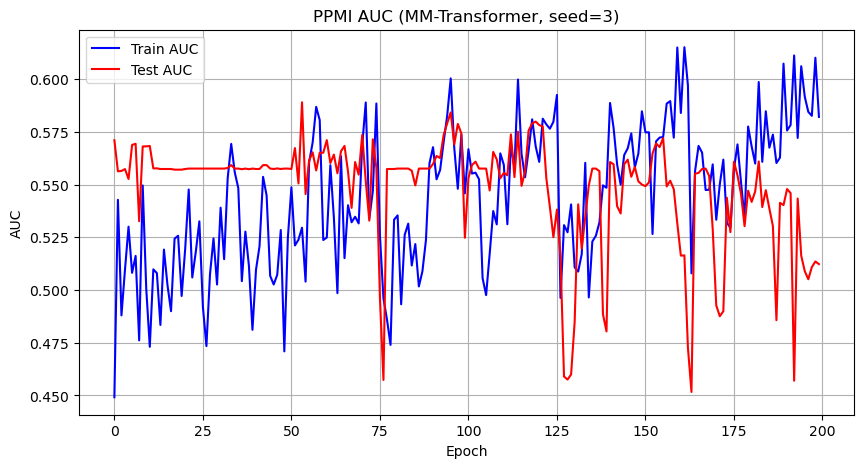

In [21]:
# Cell 5: 可视化训练曲线（以 seed=0 为例）

seed_to_check = 3
h = histories[seed_to_check]

train_aucs = h["train_auc"]      # 训练集 AUC
test_aucs  = h["val_auc"]        # 验证集 AUC，当作 test AUC

plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)),  test_aucs,  label="Test AUC",  color="red")
plt.title("PPMI AUC (MM-Transformer, seed=%d)" % seed_to_check)
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()


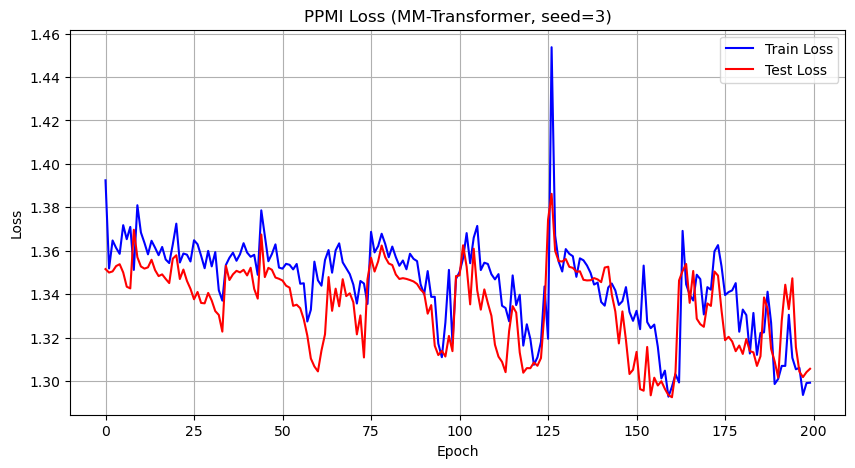

In [22]:
# Cell 5: 可视化训练曲线（以 seed=0 为例）



seed_to_check = 3
h = histories[seed_to_check]

train_losses = h["train_loss"]
test_losses  = h["val_loss"]   # 这里用验证集的 loss，当作 test curve 看

plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("PPMI Loss (MM-Transformer, seed=%d)" % seed_to_check)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
